<a href="https://colab.research.google.com/github/zebanahvi/machine-learning-projects/blob/main/EnsembleTechniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Name: Zeba Nahvi
Date: 07/10/2026
Class: Introduction to Machine Learning
Assignment: Ensemble Techniques
"""
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# load moon data and split into training and test sets
from sklearn.model_selection import train_test_split
#from sklearn.datasets import make_moons

import pandas as pd

"""
In this section we will predict whether a bank note is authentic or fake
depending upon the four different attributes of the image of the note.
The attributes are Variance of wavelet transformed image,
Kurtosis of the image, entropy, and skewness of the image.
"""

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dataset = pd.read_csv("/content/sample_data/pima-indians-diabetes.data.csv", names =
names) # to point to data
dataset.shape
dataset.head(20)
X = dataset.drop('class', axis=1)
y = dataset['class'] # class is output variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
# Bagging ensembles
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
bag_clf = BaggingClassifier(
DecisionTreeClassifier(random_state=42), n_estimators=500,
max_samples=100, bootstrap=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
# determine accuracy score for the bagging method
print(accuracy_score(y_test, y_pred))
# now use a standard decision tree classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

# compare bagging method with standard decision tree classifier

"""
HOMEWORK COMMENTARY:
The accuracy scores given by the bagging classifier and the decision tree classifier are exactly the same, at 0.7402597402597403.
"""

0.7662337662337663
0.7662337662337663


'\nHOMEWORK COMMENTARY:\nThe accuracy scores given by the bagging classifier and the decision tree classifier are exactly the same, at 0.7402597402597403.\n'

/tmp/ipykernel_2168/3435559636.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


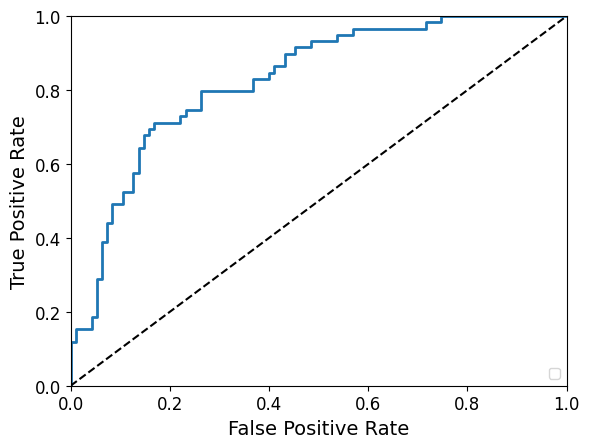

In [ ]:
# Random Forests
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

# When max_depth = 2
rnd_clf = RandomForestClassifier(n_estimators=500, max_depth = 2, n_jobs=-1,
random_state=42)
rnd_clf.fit(X_train, y_train)
y_prob_rf = rnd_clf.predict_proba(X_test)
y_pred_rf = rnd_clf.predict(X_test)
np.sum(y_pred == y_pred_rf) / len(y_pred) # almost identical predictions
y_score_rf = y_prob_rf[:,1]

fpr_rf,tpr_rf, threshold_rf = roc_curve(y_test, y_score_rf)

def plot_roc_curve(fpr, tpr, lable=None):
  plt.plot(fpr,tpr, linewidth=2)
  plt.plot([0, 1], [0, 1], 'k--')
  plt.axis([0, 1, 0, 1])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')

plot_roc_curve(fpr_rf,tpr_rf)
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_2168/2646910755.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


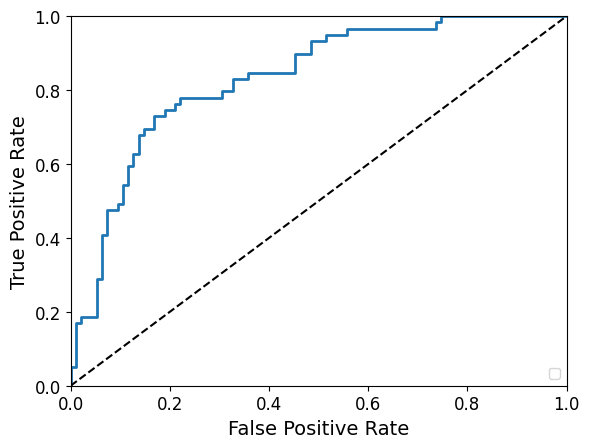

In [ ]:
rnd_clf_3 = RandomForestClassifier(n_estimators=500, max_depth = 3, n_jobs=-1,
random_state=42)
rnd_clf_3.fit(X_train, y_train)
y_prob_rf_3 = rnd_clf_3.predict_proba(X_test)
y_pred_rf_3 = rnd_clf_3.predict(X_test)
np.sum(y_pred == y_pred_rf_3) / len(y_pred) # almost identical predictions
y_score_rf_3 = y_prob_rf_3[:,1]

fpr_rf_3,tpr_rf_3, threshold_rf_3 = roc_curve(y_test, y_score_rf_3)

plot_roc_curve(fpr_rf_3,tpr_rf_3)
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_2168/2238422578.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


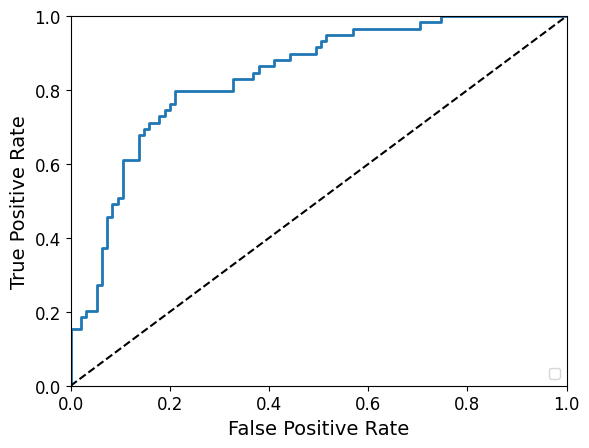

In [ ]:
# When max_depth = 4
rnd_clf_4 = RandomForestClassifier(n_estimators=500, max_depth = 4, n_jobs=-1,
random_state=42)
rnd_clf_4.fit(X_train, y_train)
y_prob_rf_4 = rnd_clf_4.predict_proba(X_test)
y_pred_rf_4 = rnd_clf_4.predict(X_test)
np.sum(y_pred == y_pred_rf_4) / len(y_pred) # almost identical predictions
y_score_rf_4 = y_prob_rf_4[:,1]

fpr_rf_4,tpr_rf_4, threshold_rf_4 = roc_curve(y_test, y_score_rf_4)

plot_roc_curve(fpr_rf_4,tpr_rf_4)
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_2168/2541391812.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


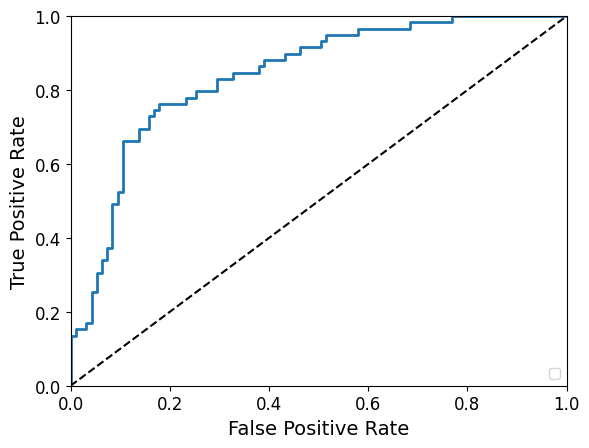

'\nHOMEWORK COMMENTARY:\nAs the maximum depth of the decision trees in the random forest classifier increases from 2 to 5,\nthe model actually performs better, as seen from the graphs attached to the pdf.\n\nThe graph gets closer and closer to the ideal true positive: false positive ratio.\n\nThis seems counterinuitive, as we were taught that trees with more than 2 nodes tend to overfit the model,\nbut perhaps for this case it is different. The Random Forest Classifier, even with a maximum depth of 5 nodes,\nappears to do well without overfitting.\n'

In [ ]:
# When max_depth = 5
rnd_clf_5 = RandomForestClassifier(n_estimators=500, max_depth = 5, n_jobs=-1,
random_state=42)
rnd_clf_5.fit(X_train, y_train)
y_prob_rf_5 = rnd_clf_5.predict_proba(X_test)
y_pred_rf_5 = rnd_clf_5.predict(X_test)
np.sum(y_pred == y_pred_rf_5) / len(y_pred) # almost identical predictions
y_score_rf_5 = y_prob_rf_5[:,1]

fpr_rf_5,tpr_rf_5, threshold_rf_5 = roc_curve(y_test, y_score_rf_5)

plot_roc_curve(fpr_rf_5,tpr_rf_5)
plt.legend(loc="lower right")
plt.show()

"""
HOMEWORK COMMENTARY:
As the maximum depth of the decision trees in the random forest classifier increases from 2 to 5,
the model actually performs better, as seen from the graphs attached to the pdf.

The graph gets closer and closer to the ideal true positive: false positive ratio.

This seems counterinuitive, as we were taught that trees with more than 2 nodes tend to overfit the model,
but perhaps for this case it is different. The Random Forest Classifier, even with a maximum depth of 5 nodes,
appears to do well without overfitting.
"""

In [ ]:
# Out-of-Bag evaluation
bag_clf = BaggingClassifier(
DecisionTreeClassifier(random_state=42), n_estimators=500,
bootstrap=True, n_jobs=-1, oob_score=True, random_state=40)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

"""
The out-of-bag evalutation revealed an accuracy score of 0.7662337662337663, which
is a bit higher compared to the initial bagging classifier accuracy score of 0.7402597402597403.
"""

'\nThe out-of-bag evalutation revealed an accuracy score of 0.7662337662337663, which\nis a bit higher compared to the initial bagging classifier accuracy score of 0.7402597402597403.\n'

In [ ]:
# Boosting method, three boosting algorithms
# First Ada boost
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(
DecisionTreeClassifier(max_depth=1), n_estimators=200,
algorithm="SAMME", learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
accuracy_score(y_test, y_pred_ada)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


0.7792207792207793

In [ ]:
# Ada boost w/ lower learning rate
from sklearn.ensemble import AdaBoostClassifier
ada_clf_low = AdaBoostClassifier(
DecisionTreeClassifier(max_depth=1), n_estimators=200,
algorithm="SAMME", learning_rate=0.25, random_state=42)
ada_clf_low.fit(X_train, y_train)
y_pred_ada_low = ada_clf_low.predict(X_test)
accuracy_score(y_test, y_pred_ada_low)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


0.7792207792207793

In [ ]:
# Ada boost w/ higher learning rate
from sklearn.ensemble import AdaBoostClassifier
ada_clf_high = AdaBoostClassifier(
DecisionTreeClassifier(max_depth=1), n_estimators=200,
algorithm="SAMME", learning_rate=0.75, random_state=42)
ada_clf_high.fit(X_train, y_train)
y_pred_ada_high = ada_clf_high.predict(X_test)

"""
HOMEWORK COMMENTARY:
The default learning rate of 0.5 yielded an accuracy score of 0.7337662337662337.
When the learning rate decreased to 0.25, the accuracy score increased to 0.7532467532467533.
However, a higher learning rate of 0.8 resulted in the lowest accuracy score of 0.7207792207792207.

In this case, the lower learning rate did the best, and the higher learning rate did the worst of the three.
"""

accuracy_score(y_test, y_pred_ada_high)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


0.7662337662337663

tree: 0.704545 (0.052038)
bag: 0.770830 (0.030873)
rnd2: 0.742208 (0.036987)
rnd3: 0.756528 (0.043412)
rnd4: 0.764320 (0.039200)
rnd5: 0.772146 (0.053327)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

ada-med: 0.755212 (0.049182)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

ada-low: 0.747403 (0.049979)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

ada-high: 0.752632 (0.050190)


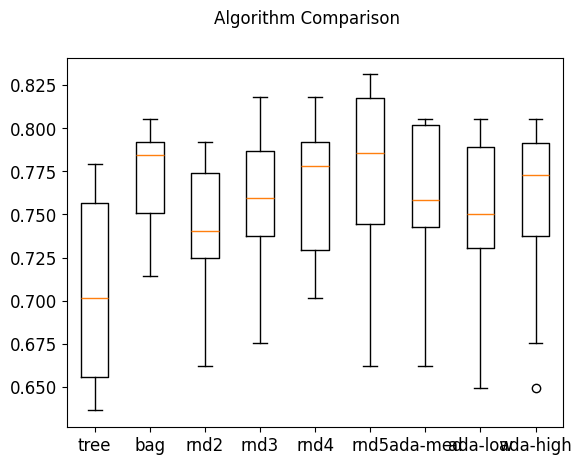

'\nHOMEWORK COMMENTARY:\n\nResults in format: accuracy score (standard deviation)\n\ntree: 0.704545 (0.052038)\nbag: 0.770830 (0.030873)\nrnd2: 0.742208 (0.036987)\nrnd3: 0.756528 (0.043412)\nrnd4: 0.764320 (0.039200)\nrnd5: 0.772146 (0.053327)\nada-med: 0.755212 (0.049182)\nada-low: 0.747403 (0.049979)\nada-high: 0.752632 (0.050190)\n\n\nAs seen from the cross-validation results, all 8 models have acceptable average accuracy\nscores that are each at least above 0.70, and have remarkably low standard deviations that\nare each less than 0.01.\n\nFrom the boxplots shown, the Random Forest Classifier with a maximum depth of 5 nodes appeared\nto perform best, as its distribution had the highest median and maximum accuracy scores. The single Decision Tree\nClassifier noticeably performed worst, with its median accuracy score just above 0.70.\n'

In [ ]:
# CROSS VALIDATION


from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from matplotlib import pyplot

models = []

models.append( ("tree", tree_clf))
models.append(("bag", bag_clf))
models.append(("rnd2", rnd_clf)) # max depth = 2
models.append(("rnd3", rnd_clf_3)) # max depth = 3
models.append(("rnd4", rnd_clf_4)) # max depth = 4
models.append(("rnd5", rnd_clf_5)) # max depth = 5
models.append(("ada-med", ada_clf))
models.append(("ada-low", ada_clf_low)) # lower learning rate 0.25
models.append(("ada-high", ada_clf_high)) # higher learning rate 0.8

results = []
names = []


for name, mod in models:
  kfold = KFold(n_splits = 10, random_state = 7, shuffle = True)
  cv_results = cross_val_score(mod, X, y, cv = kfold, scoring = 'accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

# boxplot algorithm comparison
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

"""
HOMEWORK COMMENTARY:

Results in format: accuracy score (standard deviation)

tree: 0.704545 (0.052038)
bag: 0.770830 (0.030873)
rnd2: 0.742208 (0.036987)
rnd3: 0.756528 (0.043412)
rnd4: 0.764320 (0.039200)
rnd5: 0.772146 (0.053327)
ada-med: 0.755212 (0.049182)
ada-low: 0.747403 (0.049979)
ada-high: 0.752632 (0.050190)


As seen from the cross-validation results, all 8 models have acceptable average accuracy
scores that are each at least above 0.70, and have remarkably low standard deviations that
are each less than 0.01.

From the boxplots shown, the Random Forest Classifier with a maximum depth of 5 nodes appeared
to perform best, as its distribution had the highest median and maximum accuracy scores. The single Decision Tree
Classifier noticeably performed worst, with its median accuracy score just above 0.70.
"""